# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Nur Rahmawati]
- **Email:** [nurrahmawati0217@gmail.com]
- **ID Dicoding:** [M107D5X1537]

## Import Semua Packages/Library yang Digunakan

In [18]:
import tensorflow as tf
import os
import shutil
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping, Callback
from keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

## Data Preparation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_DIR = "/content/drive/MyDrive/dataset_merged"

Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/dataset_merged.zip"
extract_path = "/content/dataset"

In [4]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done unzip!")

Done unzip!


In [5]:
data_dir = "/content/dataset/dataset_merged"

classes = sorted(os.listdir(data_dir))
print("Kelas ditemukan:", classes)

print("\nJumlah data per kelas:")
total = 0
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    count = len(os.listdir(cls_path))
    print(f"- {cls}: {count}")
    total += count

print(f"\nTOTAL SEMUA DATA: {total}")

Kelas ditemukan: ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ARCIGERA FLOWER MOTH', 'ATALA', 'ATLAS MOTH', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BANDED TIGER MOTH', 'BECKERS WHITE', 'BIRD CHERRY ERMINE MOTH', 'BLACK HAIRSTREAK', 'BLUE MORPHO', 'BLUE SPOTTED CROW', 'BROOKES BIRDWING', 'BROWN ARGUS', 'BROWN SIPROETA', 'CABBAGE WHITE', 'CAIRNS BIRDWING', 'CHALK HILL BLUE', 'CHECQUERED SKIPPER', 'CHESTNUT', 'CINNABAR MOTH', 'CLEARWING MOTH', 'CLEOPATRA', 'CLODIUS PARNASSIAN', 'CLOUDED SULPHUR', 'COMET MOTH', 'COMMON BANDED AWL', 'COMMON WOOD-NYMPH', 'COPPER TAIL', 'CRECENT', 'CRIMSON PATCH', 'DANAID EGGFLY', 'EASTERN COMA', 'EASTERN DAPPLE WHITE', 'EASTERN PINE ELFIN', 'ELBOWED PIERROT', 'EMPEROR GUM MOTH', 'GARDEN TIGER MOTH', 'GIANT LEOPARD MOTH', 'GLITTERING SAPPHIRE', 'GOLD BANDED', 'GREAT EGGFLY', 'GREAT JAY', 'GREEN CELLED CATTLEHEART', 'GREEN HAIRSTREAK', 'GREY HAIRSTREAK', 'HERCULES MOTH', 'HUMMING BIRD HAWK MOTH', 'INDRA SWALLOW', 'IO MO

### Data Loading

In [6]:
img_size = (224, 224)
batch_size = 32

raw_datagen = ImageDataGenerator()

raw_data = raw_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", raw_data.class_indices)

Found 13594 images belonging to 100 classes.
Class indices: {'ADONIS': 0, 'AFRICAN GIANT SWALLOWTAIL': 1, 'AMERICAN SNOOT': 2, 'AN 88': 3, 'APPOLLO': 4, 'ARCIGERA FLOWER MOTH': 5, 'ATALA': 6, 'ATLAS MOTH': 7, 'BANDED ORANGE HELICONIAN': 8, 'BANDED PEACOCK': 9, 'BANDED TIGER MOTH': 10, 'BECKERS WHITE': 11, 'BIRD CHERRY ERMINE MOTH': 12, 'BLACK HAIRSTREAK': 13, 'BLUE MORPHO': 14, 'BLUE SPOTTED CROW': 15, 'BROOKES BIRDWING': 16, 'BROWN ARGUS': 17, 'BROWN SIPROETA': 18, 'CABBAGE WHITE': 19, 'CAIRNS BIRDWING': 20, 'CHALK HILL BLUE': 21, 'CHECQUERED SKIPPER': 22, 'CHESTNUT': 23, 'CINNABAR MOTH': 24, 'CLEARWING MOTH': 25, 'CLEOPATRA': 26, 'CLODIUS PARNASSIAN': 27, 'CLOUDED SULPHUR': 28, 'COMET MOTH': 29, 'COMMON BANDED AWL': 30, 'COMMON WOOD-NYMPH': 31, 'COPPER TAIL': 32, 'CRECENT': 33, 'CRIMSON PATCH': 34, 'DANAID EGGFLY': 35, 'EASTERN COMA': 36, 'EASTERN DAPPLE WHITE': 37, 'EASTERN PINE ELFIN': 38, 'ELBOWED PIERROT': 39, 'EMPEROR GUM MOTH': 40, 'GARDEN TIGER MOTH': 41, 'GIANT LEOPARD MOTH':

### Data Preprocessing

#### Split Dataset

In [7]:
RAW_DIR = data_dir
dataset_split = "/content/dataset/dataset_split"

splits = ["train", "val", "test"]
ratios = (0.8, 0.1, 0.1)

for sp in splits:
    for cls in os.listdir(RAW_DIR):
        os.makedirs(f"{dataset_split}/{sp}/{cls}", exist_ok=True)

print("[OK] Folder split dibuat\n")

for cls in os.listdir(RAW_DIR):
    cls_path = os.path.join(RAW_DIR, cls)
    images = os.listdir(cls_path)

    trainval, test = train_test_split(images, test_size=ratios[2], random_state=42)
    train, val = train_test_split(trainval, test_size=ratios[1]/(ratios[0]+ratios[1]), random_state=42)

    # copy file
    for img in train:
        shutil.copy(f"{cls_path}/{img}", f"{dataset_split}/train/{cls}/{img}")
    for img in val:
        shutil.copy(f"{cls_path}/{img}", f"{dataset_split}/val/{cls}/{img}")
    for img in test:
        shutil.copy(f"{cls_path}/{img}", f"{dataset_split}/test/{cls}/{img}")

    print(f"[DONE] {cls}: {len(train)} train, {len(val)} val, {len(test)} test")

print("\n==== DONE: DATA PREPROCESSING (SPLIT DATA) ====\n")

[OK] Folder split dibuat

[DONE] MALACHITE: 89 train, 12 val, 12 test
[DONE] MESTRA: 103 train, 14 val, 13 test
[DONE] Iphiclus sister: 114 train, 15 val, 15 test
[DONE] BROWN ARGUS: 143 train, 18 val, 18 test
[DONE] ROSY MAPLE MOTH: 117 train, 15 val, 15 test
[DONE] STRAITED QUEEN: 106 train, 14 val, 14 test
[DONE] MONARCH: 110 train, 14 val, 14 test
[DONE] CHECQUERED SKIPPER: 116 train, 15 val, 15 test
[DONE] GREY HAIRSTREAK: 105 train, 14 val, 14 test
[DONE] RED SPOTTED PURPLE: 105 train, 14 val, 14 test
[DONE] PAPER KITE: 111 train, 14 val, 14 test
[DONE] POPINJAY: 103 train, 14 val, 14 test
[DONE] HUMMING BIRD HAWK MOTH: 121 train, 16 val, 16 test
[DONE] MILBERTS TORTOISESHELL: 117 train, 15 val, 15 test
[DONE] MANGROVE SKIPPER: 107 train, 14 val, 14 test
[DONE] TROPICAL LEAFWING: 102 train, 13 val, 13 test
[DONE] GREAT EGGFLY: 91 train, 12 val, 12 test
[DONE] ORANGE TIP: 117 train, 15 val, 15 test
[DONE] CLOUDED SULPHUR: 110 train, 14 val, 14 test
[DONE] PAINTED LADY: 96 train, 1

#### Data generator (normalize + augmented)

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1/255.,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1/255.)

train_loader = train_datagen.flow_from_directory(
    f"{dataset_split}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_loader = test_datagen.flow_from_directory(
    f"{dataset_split}/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_loader = test_datagen.flow_from_directory(
    f"{dataset_split}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 10783 images belonging to 100 classes.
Found 1408 images belonging to 100 classes.
Found 1403 images belonging to 100 classes.


## Modelling

In [9]:
num_classes = train_loader.num_classes

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,575,140 (55.60 MB)

 Trainable params: 14,573,156 (55.59 MB)

 Non-trainable params: 1,984 (7.75 KB)

#### Callback

In [10]:
early_stop_loss = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

class StopWhenGood(Callback):
    def __init__(self, target=0.95, patience=5):
        super().__init__()
        self.target = target
        self.patience = patience
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        if val_acc is not None and val_acc >= self.target:
            self.counter += 1
            if self.counter >= self.patience:
                print(f"\n✔ Model sudah stabil di atas {self.target*100}%")
                self.model.stop_training = True
        else:
            self.counter = 0

early_stop_good = StopWhenGood(target=0.95, patience=5)

callbacks = [early_stop_loss, early_stop_good]

In [11]:
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=60,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 160s 431ms/step - accuracy: 0.0265 - loss: 4.9116 - val_accuracy: 0.0241 - val_loss: 4.8764
Epoch 2/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 133s 395ms/step - accuracy: 0.0683 - loss: 4.2735 - val_accuracy: 0.1839 - val_loss: 3.6101
Epoch 3/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 133s 394ms/step - accuracy: 0.1203 - loss: 3.9334 - val_accuracy: 0.2699 - val_loss: 3.2435
Epoch 4/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 135s 399ms/step - accuracy: 0.1640 - loss: 3.6394 - val_accuracy: 0.3274 - val_loss: 2.8752
Epoch 5/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 132s 391ms/step - accuracy: 0.2024 - loss: 3.3484 - val_accuracy: 0.4141 - val_loss: 2.4139
Epoch 6/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 132s 391ms/step - accuracy: 0.2574 - loss: 3.0721 - val_accuracy: 0.4893 - val_loss: 2.2179
Epoch 7/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 131s 389ms/step - accuracy: 0.3032 - loss: 2.8546 - val_accuracy: 0.5170 - val_loss: 1.9261
Epoch 8/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 131s 389ms/step - accuracy: 0.3330 -

In [13]:
model.save("image_classification_model.h5")
print("Model berhasil disimpan sebagai image_classification_model.h5")

Model berhasil disimpan sebagai image_classification_model.h5


In [14]:
# Get the training and validation accuracy from the history object
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

# Evaluate the model on the test data
loss, test_accuracy = model.evaluate(test_loader)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8804 - loss: 0.5522
Training Accuracy: 0.9179
Validation Accuracy: 0.8729
Test Accuracy: 0.8753


## Visualisasi Akurasi dan Loss

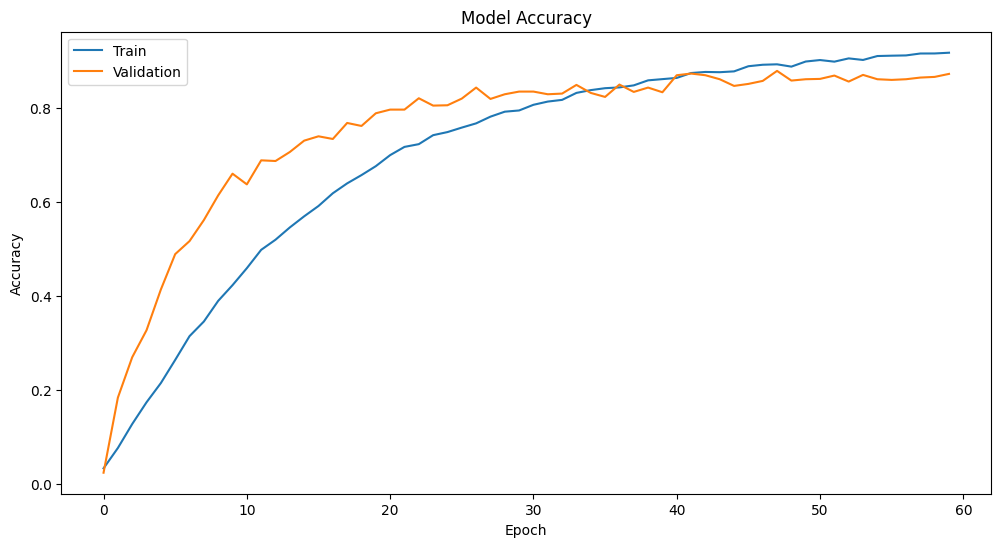

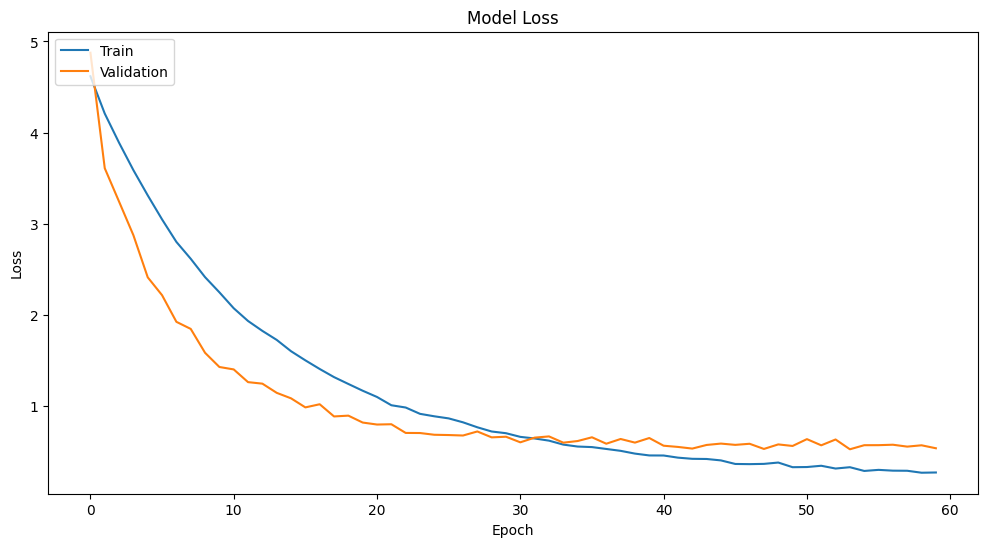

In [15]:
# Plot training and validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training and validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [19]:
num_classes = train_loader.num_classes
IMG_SIZE_MOBILENET = (224, 224, 3)

# Load MobileNetV2 pre-trained on ImageNet, excluding the top classification layer
base_model = MobileNetV2(input_shape=IMG_SIZE_MOBILENET,
                         include_top=False,
                         weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top
inputs = Input(shape=IMG_SIZE_MOBILENET)
x = base_model(inputs, training=False) # Keep base_model in inference mode when it's not trainable
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,070,884 (11.71 MB)

 Trainable params: 812,900 (3.10 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 160s 425ms/step - accuracy: 0.0304 - loss: 4.6268 - val_accuracy: 0.3580 - val_loss: 3.5420
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 128s 381ms/step - accuracy: 0.2060 - loss: 3.5141 - val_accuracy: 0.6101 - val_loss: 2.1630
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 125s 371ms/step - accuracy: 0.4067 - loss: 2.4883 - val_accuracy: 0.7053 - val_loss: 1.4740
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 126s 375ms/step - accuracy: 0.5100 - loss: 1.9229 - val_accuracy: 0.7564 - val_loss: 1.1385
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 125s 371ms/step - accuracy: 0.5785 - loss: 1.6178 - val_accuracy: 0.7919 - val_loss: 0.9538
Epoch 6/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 126s 375ms/step - accuracy: 0.6412 - loss: 1.3560 - val_accuracy: 0.8111 - val_loss: 0.8337
Epoch 7/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 125s 370ms/step - accuracy: 0.6725 - loss: 1.2113 - val_accuracy: 0.8182 - val_loss: 0.7564
Epoch 8/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 127s 375ms/step - accuracy: 0.6914 -

In [21]:
# Get the training and validation accuracy from the history object
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

# Evaluate the model on the test data
loss, test_accuracy = model.evaluate(test_loader)

print(f"Training Accuracy (MobileNetV2): {train_accuracy:.4f}")
print(f"Validation Accuracy (MobileNetV2): {val_accuracy:.4f}")
print(f"Test Accuracy (MobileNetV2): {test_accuracy:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 287ms/step - accuracy: 0.8741 - loss: 0.4701
Training Accuracy (MobileNetV2): 0.8447
Validation Accuracy (MobileNetV2): 0.8885
Test Accuracy (MobileNetV2): 0.8696


## Visualisasi Akurasi dan Loss (MobileNetV2)

In [ ]:
# Plot training and validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy (MobileNetV2)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training and validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (MobileNetV2)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Konversi Model

In [30]:
num_classes = train_loader.num_classes

manual_cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

manual_cnn_model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define the path to save the manual CNN model
saved_manual_cnn_path = "./manual_cnn_saved_model"

# Create the directory if it doesn't exist
os.makedirs(saved_manual_cnn_path, exist_ok=True)

# Save the manual CNN model in TensorFlow SavedModel format using model.export()
manual_cnn_model.export(saved_manual_cnn_path)

print(f"Manual CNN model saved to: {saved_manual_cnn_path}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved artifact at './manual_cnn_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_360')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  139317827925200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827923664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827926352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827927312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827917520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827925584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827925776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827925392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827921360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139317827927888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

In [31]:
# Define the path to the saved manual CNN model (SavedModel format)
saved_manual_cnn_path = "./manual_cnn_saved_model"

# Define the path for the TensorFlow Lite model
tflite_model_path = "./manual_cnn_tflite/manual_cnn.tflite"

# Create the directory for TFLite model if it doesn't exist
os.makedirs(os.path.dirname(tflite_model_path), exist_ok=True)

# Convert the SavedModel to TFLite format
converter = tf.lite.TFLiteConverter.from_saved_model(saved_manual_cnn_path)
tflite_model = converter.convert()

# Save the TFLite model
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"Manual CNN model converted to TensorFlow Lite and saved to: {tflite_model_path}")

Manual CNN model converted to TensorFlow Lite and saved to: ./manual_cnn_tflite/manual_cnn.tflite


In [35]:
import tensorflow as tf
import os

# Define the input path for the TensorFlow SavedModel of the manual CNN model
saved_manual_cnn_path = "./manual_cnn_saved_model"

# Define an output directory for the TensorFlow.js model of the manual CNN
tfjs_manual_cnn_path = "./manual_cnn_tfjs"

# Create the output directory if it doesn't already exist
os.makedirs(tfjs_manual_cnn_path, exist_ok=True)

# Use the tensorflowjs_converter command-line tool to convert the SavedModel to TensorFlow.js format
# The command should specify the input format as `tf_saved_model` and the output format as `tfjs_graph_model`
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    "$saved_manual_cnn_path" \
    "$tfjs_manual_cnn_path"

print(f"Manual CNN model converted to TensorFlow.js and saved to: {tfjs_manual_cnn_path}")

2025-11-18 14:32:14.117627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763476334.137169   57353 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763476334.143028   57353 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763476334.157725   57353 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763476334.157751   57353 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763476334.157755   57353 computation_placer.cc:177] computation placer alr

In [28]:
# Define the path to save the SavedModel
saved_model_path = "./mobilenetv2_saved_model"

# Create the directory if it doesn't exist
os.makedirs(saved_model_path, exist_ok=True)

# Save the MobileNetV2 model in TensorFlow SavedModel format using model.export()
model.export(saved_model_path)

print(f"MobileNetV2 model saved to: {saved_model_path}")

Saved artifact at './mobilenetv2_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_330')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  139315230668560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230669328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230669136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230667792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230669904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230665488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230669520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230668944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230670672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139315230670096: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

In [33]:
# Define the path to the saved MobileNetV2 model (SavedModel format)
saved_model_path = "./mobilenetv2_saved_model"

# Define the path for the TensorFlow Lite model
tflite_model_path = "./mobilenetv2_tflite/mobilenetv2.tflite"

# Create the directory for TFLite model if it doesn't exist
os.makedirs(os.path.dirname(tflite_model_path), exist_ok=True)

# Convert the SavedModel to TFLite format
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

# Save the TFLite model
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"MobileNetV2 model converted to TensorFlow Lite and saved to: {tflite_model_path}")

MobileNetV2 model converted to TensorFlow Lite and saved to: ./mobilenetv2_tflite/mobilenetv2.tflite


In [34]:
import tensorflow as tf
import os

# Define the input path for the TensorFlow SavedModel of the MobileNetV2 model
saved_model_path = "./mobilenetv2_saved_model"

# Define an output directory for the TensorFlow.js model
tfjs_model_path = "./mobilenetv2_tfjs"

# Create the output directory if it doesn't already exist
os.makedirs(tfjs_model_path, exist_ok=True)

# Use the tensorflowjs_converter command-line tool to convert the SavedModel to TensorFlow.js format
# The command should specify the input format as `tf_saved_model` and the output format as `tfjs_graph_model`
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    "$saved_model_path" \
    "$tfjs_model_path"

print(f"MobileNetV2 model converted to TensorFlow.js and saved to: {tfjs_model_path}")

2025-11-18 14:31:45.637965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763476305.657910   57201 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763476305.663932   57201 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763476305.679401   57201 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763476305.679435   57201 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763476305.679439   57201 computation_placer.cc:177] computation placer alr

## Inference (Optional)

Model berhasil dimuat dari: ./mobilenetv2_saved_model

Menggunakan gambar contoh: /content/dataset/dataset_split/test/MALACHITE/103.jpg
Kelas yang Diprediksi: MALACHITE
Keyakinan Prediksi: 0.84


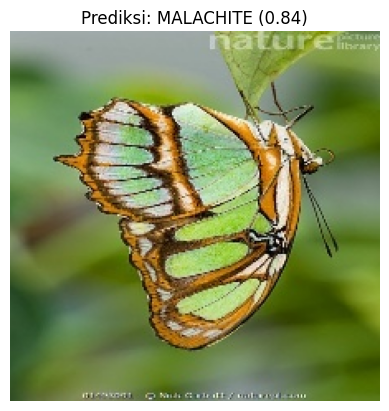

In [37]:
# Path ke SavedModel MobileNetV2
saved_model_path = "./mobilenetv2_saved_model"

# Memuat model yang telah disimpan
try:
    loaded_model = tf.saved_model.load(saved_model_path)
    print(f"Model berhasil dimuat dari: {saved_model_path}")
except Exception as e:
    print(f"Gagal memuat model: {e}")
    loaded_model = None

if loaded_model:
    # Fungsi untuk memuat dan mempersiapkan gambar untuk inferensi
    def preprocess_image_for_inference(img_path, target_size=(224, 224)):
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch
        img_array = img_array / 255.0  # Normalisasi seperti saat pelatihan
        return img_array

    # Dapatkan mapping indeks kelas dari train_loader
    # Pastikan train_loader masih tersedia atau muat ulang jika perlu
    if 'train_loader' in locals() or 'train_loader' in globals():
        class_indices = train_loader.class_indices
        idx_to_class = {v: k for k, v in class_indices.items()}
    else:
        # Fallback jika train_loader tidak tersedia
        print("Warning: train_loader tidak tersedia. Tidak bisa mendapatkan class_indices.")
        idx_to_class = None # Anda mungkin perlu memuat ulang data generator atau mendefinisikan ini secara manual

    # === Contoh Penggunaan Inferensi ===
    # Pastikan Anda memiliki contoh gambar di dataset_split/test
    # Ganti dengan path ke salah satu gambar di folder test Anda
    sample_image_path = None
    for root, dirs, files in os.walk(f"{dataset_split}/test"): # Ganti dataset_split jika tidak ada
        if files:
            sample_image_path = os.path.join(root, files[0])
            break

    if sample_image_path:
        print(f"\nMenggunakan gambar contoh: {sample_image_path}")
        # Preprocessing gambar
        processed_image = preprocess_image_for_inference(sample_image_path)

        # Lakukan prediksi
        # Asumsi fungsi inferensi model disimpan di 'signatures["serving_default"]'
        # atau panggil langsung jika model memiliki metode __call__
        if hasattr(loaded_model, 'signatures'):
            infer_fn = loaded_model.signatures["serving_default"]
            predictions = infer_fn(tf.constant(processed_image, dtype=tf.float32))
            # Ekstrak tensor output jika diperlukan, e.g., 'output_0'
            if 'output_0' in predictions: # Periksa nama output sesuai SavedModel
                predictions = predictions['output_0'].numpy()
            else: # Coba akses langsung jika hanya ada satu output
                predictions = list(predictions.values())[0].numpy()
        else:
            # Jika model dimuat dengan keras.models.load_model, panggil langsung
            predictions = loaded_model(processed_image).numpy()

        # Dapatkan kelas prediksi teratas
        predicted_class_idx = np.argmax(predictions)
        confidence = np.max(predictions)

        if idx_to_class:
            predicted_class_name = idx_to_class[predicted_class_idx]
            print(f"Kelas yang Diprediksi: {predicted_class_name}")
        else:
            print(f"Indeks Kelas yang Diprediksi: {predicted_class_idx}")
        print(f"Keyakinan Prediksi: {confidence:.2f}")

        # Tampilkan gambar asli (opsional)
        import matplotlib.pyplot as plt
        original_img = image.load_img(sample_image_path)
        plt.imshow(original_img)
        plt.title(f"Prediksi: {predicted_class_name if idx_to_class else predicted_class_idx} ({confidence:.2f})")
        plt.axis('off')
        plt.show()

    else:
        print("Tidak ada gambar contoh yang ditemukan untuk inferensi. Pastikan dataset_split/test terisi.")
else:
    print("Tidak dapat melanjutkan inferensi karena model gagal dimuat.")


**Reasoning**:
To install the `tensorflowjs` library as instructed, I need to execute a pip install command in a code block.



In [22]:
pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.4 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.10.1 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.38.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [36]:
!pip freeze > requirements.txt
print("Generated requirements.txt")

Generated requirements.txt
